# Diffusion models (DDPM) — a runnable, measured, *proven* build

A **diffusion model** generates by learning to **reverse a fixed noising process**. Add a little Gaussian noise to real data, over and over, until it becomes pure static $\mathcal N(0,I)$ (the **forward** process, no learning). Then train one network to undo *one* small noising step; generate by starting from static and denoising step by step (the **reverse** process). The whole thing collapses to a network that **predicts the noise**, trained with plain MSE.

This notebook builds a DDPM **from scratch** on a **real 2-D distribution** (`sklearn` `make_moons`) — chosen so you can *watch* the data dissolve into noise and reassemble — and *proves* the two claims that matter:

- **The closed-form forward is exact.** We check with a hard `assert` that the one-shot jump $q(x_t\mid x_0)=\mathcal N(\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I)$ equals the distribution of the slow, step-by-step noising chain.
- **The model generates the target.** We `assert` that samples drawn from the trained reverse chain match the real two-moons (energy distance far below the $\mathcal N(0,I)$ baseline).

It imports the **exact same functions** as the companion page and its figures (from `ddpm.py`), so the numbers here are the numbers there. Everything is **seeded and CPU-pinned** for a reproducible trace.

> Companion page: **Diffusion Models (DDPM)**. Run top-to-bottom (Kernel → Restart & Run All). The 2-D demo trains in well under a minute on CPU.

## Step 0 — Setup: import the real module and print versions

We import the pipeline from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions and the device. Training pins **CPU** for a reproducible trace (a small MLP denoiser on 2-D points trains fast on CPU).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import ddpm as D

print(f'torch {torch.__version__} | numpy {np.__version__}')
print(f'best available device = {D.get_device()}  (training pinned to CPU for reproducibility, seed={D.SEED})')

torch 2.12.0 | numpy 2.4.6
best available device = mps  (training pinned to CPU for reproducibility, seed=0)


## Step 1 — The data: a real 2-D distribution (two moons), standardized

We sample the real `make_moons` distribution — two interleaving crescents — and **standardize** it to zero-mean / unit-variance so that $\mathcal N(0,I)$ is the right target for the forward process. This is genuinely 2-D, non-Gaussian, and multi-modal: a distribution the model must *learn*, not one it starts from.

dataset : sklearn make_moons (2-D)   |   (4000, 2) points, standardized


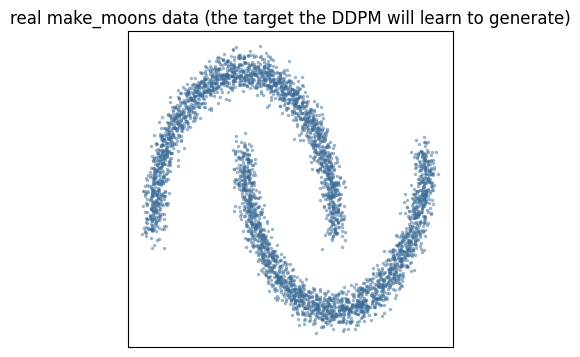

In [2]:
data = D.load_moons(seed=0)
print(f'dataset : {data.label}   |   {tuple(data.x.shape)} points, standardized')

plt.figure(figsize=(4.2, 4.2))
plt.scatter(data.x[:, 0], data.x[:, 1], s=6, c='#3A6B96', alpha=0.5, linewidths=0)
plt.gca().set_aspect('equal')
plt.xticks([])
plt.yticks([])
plt.title('real make_moons data (the target the DDPM will learn to generate)')
plt.show()

## Step 2 — The noise schedule: β, α, and the all-important ᾱ

The forward process adds noise on a fixed **variance schedule** $\beta_1,\dots,\beta_T$. From it we precompute $\alpha_t=1-\beta_t$ and the **compounded signal-survival** $\bar\alpha_t=\prod_{s\le t}\alpha_s$ — the single most important quantity: the closed-form forward has mean $\sqrt{\bar\alpha_t}x_0$ and variance $1-\bar\alpha_t$. Watch $\bar\alpha_t$ fall from 1 (all signal) to $\approx 0$ (all noise).

T = 400   beta in [0.0001, 0.0200]   abar_T = 0.0175  (x_T is essentially N(0, I))


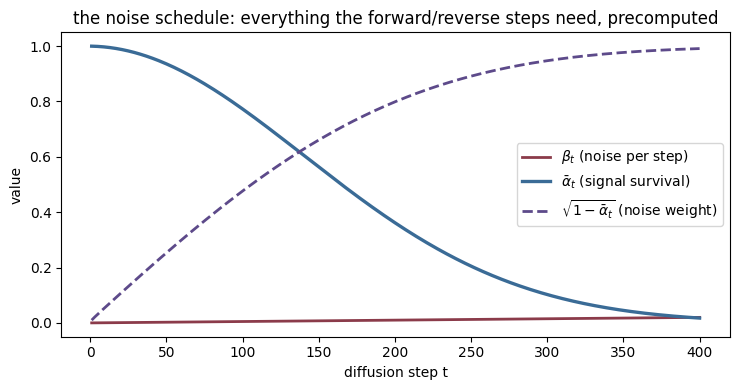

In [3]:
sched = D.make_schedule(kind='linear', T=D.T_STEPS)
t = np.arange(1, sched.T + 1)
print(f'T = {sched.T}   beta in [{sched.betas[0]:.4f}, {sched.betas[-1]:.4f}]   abar_T = {sched.alpha_bars[-1]:.4f}  (x_T is essentially N(0, I))')

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(t, sched.betas, color='#8B3B4A', lw=2, label=r'$\beta_t$ (noise per step)')
ax.plot(t, sched.alpha_bars, color='#3A6B96', lw=2.4, label=r'$\bar\alpha_t$ (signal survival)')
ax.plot(t, sched.sqrt_one_minus_abar, color='#5D4A8A', lw=2, ls='--', label=r'$\sqrt{1-\bar\alpha_t}$ (noise weight)')
ax.set_xlabel('diffusion step t')
ax.set_ylabel('value')
ax.legend()
ax.set_title('the noise schedule: everything the forward/reverse steps need, precomputed')
plt.tight_layout()
plt.show()

## Step 3 — The forward process: jump to any noise level in one shot

The **nice property**: instead of simulating $t$ noising steps, jump straight to any $x_t$ with

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,I).$$

We apply `q_sample` at increasing $t$ and watch the two moons dissolve into an isotropic Gaussian.

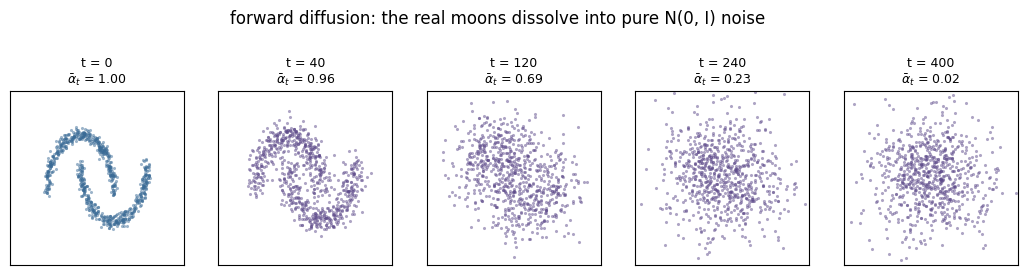

In [4]:
torch.manual_seed(0)
x0 = data.x[:800]
eps = torch.randn_like(x0)  # shared noise so the same cloud dissolves coherently
ts = [0, 40, 120, 240, sched.T]
fig, axes = plt.subplots(1, len(ts), figsize=(13, 2.7))
for ax, tt in zip(axes, ts):
    if tt == 0:
        pts = x0
    else:
        idx = torch.full((x0.shape[0],), tt - 1, dtype=torch.long)
        pts, _ = D.q_sample(x0, idx, sched, eps=eps)
    ax.scatter(pts[:, 0], pts[:, 1], s=5, c='#3A6B96' if tt == 0 else '#5D4A8A', alpha=0.5, linewidths=0)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    abar = 1.0 if tt == 0 else float(sched.alpha_bars[tt - 1])
    ax.set_title(f't = {tt}\n' + r'$\bar\alpha_t$ = ' + f'{abar:.2f}', fontsize=9)
plt.suptitle('forward diffusion: the real moons dissolve into pure N(0, I) noise', y=1.12)
plt.show()

## Step 4 — Proof: the closed form *is* the iterative chain

The whole method rests on the one-shot jump equalling the slow, step-by-step chain. We check it: fix a single $x_0$, run the **iterative** forward ($t=240$ tiny Gaussian steps) $N=60{,}000$ times, and compare the empirical mean and covariance to the closed-form $\sqrt{\bar\alpha_t}x_0$ and $(1-\bar\alpha_t)I$. `assert` they agree.

In [5]:
fp = D.prove_forward_closed_form(sched)
print(f'at t = {fp.t}:  abar_t = {fp.abar_t:.4f}')
print(f'closed-form mean = {fp.closed_mean.round(4)}   iterative mean = {fp.iter_mean.round(4)}  (N={fp.n_rollouts:,})')
print(f'closed-form var  = {fp.closed_var:.4f}         iterative cov diag = {np.diag(fp.iter_cov).round(4)}')
print(f'max|mean err| = {fp.mean_abs_err:.2e}   max|cov err| = {fp.var_abs_err:.2e}')
assert fp.mean_abs_err < 0.05 and fp.var_abs_err < 0.05
print('OK: the one-shot q_sample is exactly the marginal of the compounded chain — the nice property holds.')

at t = 240:  abar_t = 0.2322
closed-form mean = [ 0.5782 -0.3373]   iterative mean = [ 0.5794 -0.3414]  (N=60,000)
closed-form var  = 0.7678         iterative cov diag = [0.7653 0.7689]
max|mean err| = 4.09e-03   max|cov err| = 2.50e-03
OK: the one-shot q_sample is exactly the marginal of the compounded chain — the nice property holds.


## Step 5 — The denoiser $\varepsilon_\theta(x_t, t)$: predict the noise

The learned part is one small network that takes a noised point $x_t$ and its timestep $t$ and predicts the **noise** that was added. The timestep is fed through a **sinusoidal embedding** (like transformer positions) so one network can behave differently at every noise level.

In [6]:
model = D.Denoiser2D(dim=2)
n_params = sum(p.numel() for p in model.parameters())
print(f'denoiser: {n_params:,} parameters  (a small MLP + sinusoidal time embedding)')
xb = data.x[:5]
t_batch = torch.full((5,), 100.0)
eps_pred = model(xb, t_batch)
print(f'input x_t {tuple(xb.shape)}, timestep t {tuple(t_batch.shape)}  ->  predicted noise {tuple(eps_pred.shape)}  (same shape as the data)')

denoiser: 74,882 parameters  (a small MLP + sinusoidal time embedding)
input x_t (5, 2), timestep t (5,)  ->  predicted noise (5, 2)  (same shape as the data)


## Step 6 — The loss: $L_{\text{simple}}=\mathbb E\,\|\varepsilon-\varepsilon_\theta(x_t,t)\|^2$

Training is plain MSE: draw a random timestep $t$ and noise $\varepsilon$, form $x_t$ with the closed-form jump, and regress the network's prediction onto the *true* noise. No adversary, no KL to balance — the variational bound reduces to this after the $\varepsilon$-parameterization.

In [7]:
g = torch.Generator().manual_seed(0)
loss = D.diffusion_loss(model, data.x[:256], sched, generator=g)
print(f'L_simple on one batch (untrained model) = {loss.item():.4f}   (~1.0: predicting noise no better than zero)')

L_simple on one batch (untrained model) = 1.1489   (~1.0: predicting noise no better than zero)


## Step 7 — Train the denoiser from scratch

Now the full loop: for each minibatch, sample random timesteps and noise, form $x_t$, predict the noise, take the MSE, one Adam step. Watch $L_{\text{simple}}$ fall. (A real training run — about 20 seconds on CPU.)

trained 700 epochs in 18.1s  |  L_simple: 0.961 -> 0.369


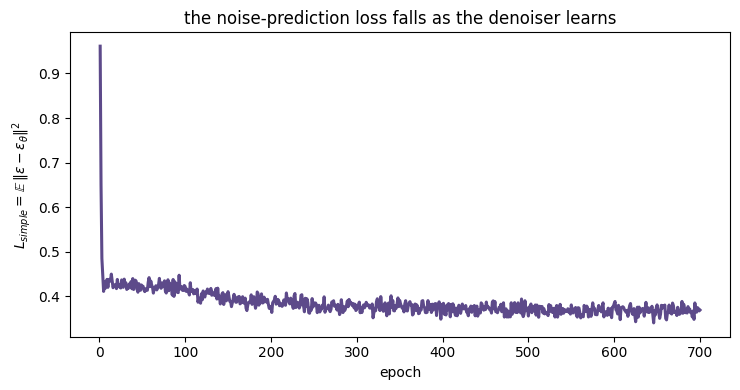

In [8]:
res = D.train_ddpm(data, sched, n_epochs=D.N_EPOCHS, seed=0)
print(f'trained {D.N_EPOCHS} epochs in {res.seconds:.1f}s  |  L_simple: {res.loss_hist[0]:.3f} -> {res.final_loss:.3f}')

ep = np.arange(1, len(res.loss_hist) + 1)
plt.figure(figsize=(7.5, 4))
plt.plot(ep, res.loss_hist, color='#5D4A8A', lw=2.2)
plt.xlabel('epoch')
plt.ylabel(r'$L_{simple}=\mathbb{E}\,\|\varepsilon-\varepsilon_\theta\|^2$')
plt.title('the noise-prediction loss falls as the denoiser learns')
plt.tight_layout()
plt.show()

## Step 8 — Generate: run the reverse chain from pure noise

Generation is **ancestral sampling**: start from $x_T\sim\mathcal N(0,I)$ and, for $t=T,\dots,1$, apply the learned reverse step

$$x_{t-1}=\tfrac{1}{\sqrt{\alpha_t}}\big(x_t-\tfrac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\big)+\sigma_t z.$$

We record the cloud at several timesteps — watch the two-moons condense out of the noise (it happens late!).

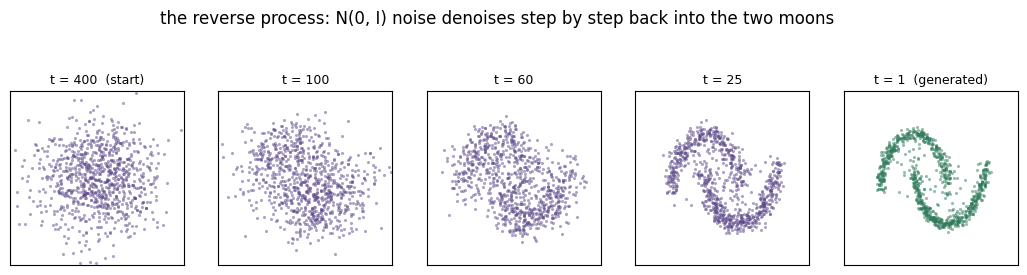

In [9]:
_, traj = D.p_sample_loop(res.model, sched, n=900, dim=2, seed=7, record_every=1)
by_t = {tt: cloud for tt, cloud in traj}
want = [sched.T, 100, 60, 25, 1]
snaps = [(tt, by_t[min(by_t, key=lambda k: abs(k - tt))]) for tt in want]
fig, axes = plt.subplots(1, len(snaps), figsize=(13, 2.7))
for ax, (tt, cloud) in zip(axes, snaps):
    c = cloud.numpy()
    ax.scatter(c[:, 0], c[:, 1], s=5, c='#2E7A5A' if tt == 1 else '#5D4A8A', alpha=0.5, linewidths=0)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f't = {tt}' + ('  (start)' if tt == sched.T else '  (generated)' if tt == 1 else ''), fontsize=9)
plt.suptitle('the reverse process: N(0, I) noise denoises step by step back into the two moons', y=1.12)
plt.show()

## Step 9 — Proof: the generated samples match the target

A small loss is not the same as good generation — we test it *directly*. Draw samples from the trained chain and score them against the real target with the **energy distance** (a two-sample statistic, zero iff the distributions match). Compare to the $\mathcal N(0,I)$ baseline (the chain's starting cloud). `assert` the generated samples are far closer to the target.

In [10]:
gp = D.prove_generation(res, data)
print(f'energy distance  generated  vs target = {gp.ed_generated:.4f}')
print(f'energy distance  N(0,I) base vs target = {gp.ed_baseline:.4f}   (the chain started here)')
print(f'ratio = {gp.ratio:.3f}   -> generated is {1/gp.ratio:.1f}x closer to the target than pure noise')
assert gp.ratio < 0.5
print('OK: the reverse chain learned the distribution, it did not just echo its Gaussian start.')

energy distance  generated  vs target = 0.0596
energy distance  N(0,I) base vs target = 0.2164   (the chain started here)
ratio = 0.275   -> generated is 3.6x closer to the target than pure noise
OK: the reverse chain learned the distribution, it did not just echo its Gaussian start.


## Step 10 — The payoff: generated points sit on the real manifold

Overlay the generated samples on the real data. They should land on the two crescents — same shape, same gap — the geometry reproduced from pure noise, having only ever learned to undo one small step.

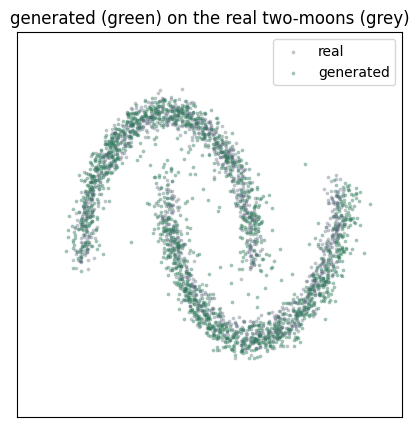

In [11]:
gen, _ = D.p_sample_loop(res.model, sched, n=1500, dim=2, seed=11)
gen = gen.numpy()
plt.figure(figsize=(5, 5))
plt.scatter(data.x[:1500, 0], data.x[:1500, 1], s=7, c='#4A5B6E', alpha=0.35, linewidths=0, label='real')
plt.scatter(gen[:, 0], gen[:, 1], s=7, c='#2E7A5A', alpha=0.45, linewidths=0, label='generated')
plt.gca().set_aspect('equal')
plt.xlim(-2.6, 2.6)
plt.ylim(-2.6, 2.6)
plt.xticks([])
plt.yticks([])
plt.legend()
plt.title('generated (green) on the real two-moons (grey)')
plt.show()

## Step 11 — Linear vs cosine schedule

The **cosine** schedule (Nichol & Dhariwal, 2021) adds noise more gently near the ends, keeping $\bar\alpha_t$ higher for longer — better likelihoods and samples on images than the linear schedule. Compare the two $\bar\alpha_t$ curves.

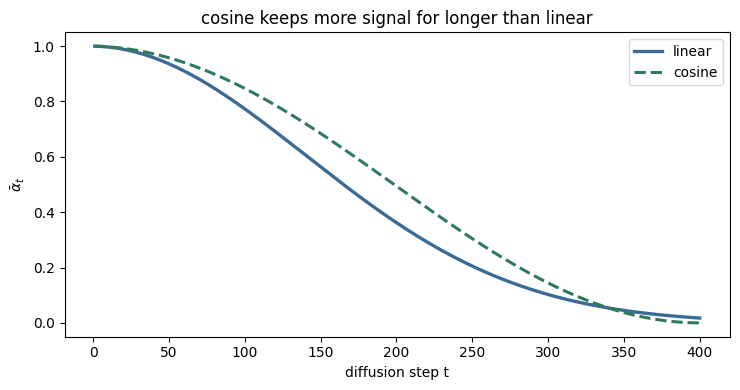

In [12]:
cos = D.make_schedule(kind='cosine', T=D.T_STEPS)
t = np.arange(1, sched.T + 1)
plt.figure(figsize=(7.5, 4))
plt.plot(t, sched.alpha_bars, color='#3A6B96', lw=2.4, label='linear')
plt.plot(t, cos.alpha_bars, color='#2E7A5A', lw=2.2, ls='--', label='cosine')
plt.xlabel('diffusion step t')
plt.ylabel(r'$\bar\alpha_t$')
plt.legend()
plt.title('cosine keeps more signal for longer than linear')
plt.tight_layout()
plt.show()

## Step 12 — Try it: predict, then check

Before running, *predict the direction*. We cut $T$ from 400 to **50** and retrain. With so few steps, $\bar\alpha_T$ no longer reaches $\approx 0$ — so $x_T$ still carries a lot of signal, and sampling from $\mathcal N(0,I)$ starts from the *wrong* place. Will the generated-vs-target energy distance get **worse**? Write your guess, then check.

In [13]:
sched50 = D.make_schedule(kind='linear', T=50)
print(f'T=50:  abar_T = {sched50.alpha_bars[-1]:.3f}  (NOT near 0 -> x_T keeps signal, prior mismatch)')
res50 = D.train_ddpm(data, sched50, n_epochs=400, seed=0)
gp50 = D.prove_generation(res50, data)
print(f'T=400 (trained above): generated-vs-target energy distance = {gp.ed_generated:.4f}  (ratio {gp.ratio:.2f})')
print(f'T=50:                  generated-vs-target energy distance = {gp50.ed_generated:.4f}  (ratio {gp50.ratio:.2f})')
print('Too few steps -> abar_T not ~0 -> worse samples. More (finer) steps = easier reverse = better samples, but slower sampling.')

T=50:  abar_T = 0.603  (NOT near 0 -> x_T keeps signal, prior mismatch)


T=400 (trained above): generated-vs-target energy distance = 0.0596  (ratio 0.28)
T=50:                  generated-vs-target energy distance = 0.0728  (ratio 0.34)
Too few steps -> abar_T not ~0 -> worse samples. More (finer) steps = easier reverse = better samples, but slower sampling.


## Recap

You built a DDPM from scratch and **proved** it: the closed-form forward $q(x_t\mid x_0)=\mathcal N(\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I)$ equals the slow iterative noising chain (the *nice property* that lets training jump to any $t$), and a from-scratch denoiser trained by $L_{\text{simple}}=\mathbb E\|\varepsilon-\varepsilon_\theta\|^2$ **generates** the real two-moons target (energy distance far below the $\mathcal N(0,I)$ baseline). Generation is ancestral sampling down the learned reverse chain — slow, because it runs all $T$ steps.

See the companion page for the full derivation (the compounding of $\bar\alpha_t$, the variational bound as a sum of Gaussian KLs, the $\varepsilon$-parameterization that yields $L_{\text{simple}}$, the sampling update), the pitfalls (slow sampling, the reweighted bound, schedule choice, the timestep embedding), and where it goes next: a DDPM is a **hierarchical VAE with a fixed encoder**, predicting noise is **learning the score**, and running this exact loop in a VAE's latent space is **Stable Diffusion**.